# Tuning FLORIS using ModelFit

Demonstrate tuning of FLORIS to the SCADA data using the ModelFit object

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from optuna.visualization.matplotlib import (
    plot_contour,
    plot_slice,
)

from flasc.data_processing.dataframe_manipulations import (
    is_day_or_night,
)
from flasc.model_fit.model_fit import ModelFit
from flasc.model_fit.opt_library import atomic_opt_optuna
from flasc.utilities.utilities_examples import load_floris_smarteole

## Parameters

In [2]:
# Number of trials per optimization
n_trials = 20

## Read data and prepare data

Use previously definied 60s data and condition the data as before

In [3]:
# Read in data
root_path = Path.cwd()
f = root_path / "postprocessed" / "df_scada_data_60s_filtered_and_northing_calibrated.pkl"
df_scada = pd.read_pickle(f)

In [4]:
# Add day/night boolean to SCADA data
latitude = 49.8435
longitude = 2.801556

# Compute day/night in default settings and plot
df_scada = is_day_or_night(df_scada, latitude, longitude)

In [5]:
# Limit SCADA data to region of wake steering

# Specify offsets
start_of_offset = 200  # deg
end_of_offset = 240  # deg

# Limit SCADA to this region
df_scada = df_scada[
    (df_scada.wd_smarteole > (start_of_offset - 20))
    & (df_scada.wd_smarteole < (end_of_offset + 20))
]

In [6]:
# Assign wd, ws and pow ref and subset SCADA based on reference variables used
# in the SMARTEOLE wake steering experiment (TODO reference the experiment)
df_scada = df_scada.assign(
    wd=lambda df_: df_["wd_smarteole"],
    ws=lambda df_: df_["ws_smarteole"],
    pow_ref=lambda df_: df_["pow_ref_smarteole"],
).reset_index(drop=True)

## Load FLORIS Model

In [7]:
fm, _ = load_floris_smarteole(wake_model="emgauss")
D = fm.core.farm.rotor_diameters[0]

## Split the data into sub groups

In [8]:
# Split SCADA into baseline and wake steeering (controlled)
df_scada_baseline = df_scada[df_scada.control_mode == "baseline"].reset_index(drop=True).copy()
df_scada_controlled = df_scada[df_scada.control_mode == "controlled"].reset_index(drop=True).copy()

In [9]:
# Further split SCADA into day and night
df_scada_baseline_day = df_scada_baseline[df_scada_baseline.is_day].reset_index(drop=True).copy()
df_scada_baseline_night = df_scada_baseline[~df_scada_baseline.is_day].reset_index(drop=True).copy()
df_scada_controlled_day = (
    df_scada_controlled[df_scada_controlled.is_day].reset_index(drop=True).copy()
)
df_scada_controlled_night = (
    df_scada_controlled[~df_scada_controlled.is_day].reset_index(drop=True).copy()
)

## Tuning recovery on baseline data

The first element of the wake expansion parameter array is named we_1 in this analysis.  It governs the wake expansion in the empirical gaussian model up to the first defined breakpoint (often 10D).  Given the close spacing it is only necessary to tune this parameter.

First define the parameter for model fit

In [10]:
# Just tune the first wake expansion parameter
parameter_list = [
    (
        "wake",
        "wake_velocity_parameters",
        "empirical_gauss",
        "wake_expansion_rates",
    )
]

parameter_name_list = [
    "we_1",
]

parameter_range_list = [
    (0.0, 0.05),
]

parameter_index_list = [0]

## Custom cost function

In [11]:
# ModelFit provides a number of pre-defined cost functions in the cost_library module
# However in this work, define a cost function that only uses the downstream turbine power
# Turbine 004 is the downstream turbine
def turbine_power_error_abs_004(
    df_scada,
    df_floris,
    fm_,
    turbine_groupings=None,
):
    """Evaluate error with respect to downstream turbine power.

    Args:
        df_scada (pd.DataFrame): SCADA data
        df_floris (pd.DataFrame): FLORIS data
        fm_ (FlorisModel): FLORIS model (Unused but required for compatibility)
        turbine_groupings (List): List of turbine groupings.  Defaults to None.
            In None case, assumes pow_ref and pow_test are already identified (note
            this can be challenging to effect within FLORIS resimulation results).

    Returns:
        float: Overall wake losses

    """

    # Compute the mean absolute error
    return (df_scada["pow_004"] - df_floris["pow_004"]).abs().mean()

# Baseline tuning

Tune we_1 to the best fit for all the baseline data

In [12]:
# Model Fit object
mf = ModelFit(
    df_scada_baseline,
    fm,
    turbine_power_error_abs_004,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

In [13]:
# Run the optimization for n_trials
opt_result, study = atomic_opt_optuna(mf, timeout=None, n_trials=n_trials)

[I 2025-08-05 16:29:59,911] A new study created in memory with name: ModelFit
[I 2025-08-05 16:30:01,589] Trial 0 finished with value: 147.31745684375417 and parameters: {'we_1': 0.01}. Best is trial 0 with value: 147.31745684375417.
[I 2025-08-05 16:30:03,627] Trial 1 finished with value: 148.52946383320494 and parameters: {'we_1': 0.02744067519636624}. Best is trial 0 with value: 147.31745684375417.
[I 2025-08-05 16:30:05,627] Trial 2 finished with value: 153.21738794515898 and parameters: {'we_1': 0.03575946831862097}. Best is trial 0 with value: 147.31745684375417.
[I 2025-08-05 16:30:07,530] Trial 3 finished with value: 149.87308625406902 and parameters: {'we_1': 0.030138168803582194}. Best is trial 0 with value: 147.31745684375417.
[I 2025-08-05 16:30:09,449] Trial 4 finished with value: 148.44049237919037 and parameters: {'we_1': 0.027244159149844845}. Best is trial 0 with value: 147.31745684375417.
[I 2025-08-05 16:30:11,493] Trial 5 finished with value: 146.30170645058936 and 

In [14]:
# Print the best result
we_1_baseline = opt_result["parameter_values"][0]

print(f"Best we_1 from baseline tuning: {we_1_baseline}")


Best we_1 from baseline tuning: 0.016248181802607925


/var/folders/zl/d69s6z796rs4fw08fnxrl0qxydms74/T/ipykernel_50079/2662486793.py:3: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(study)


<Axes: title={'center': 'Slice Plot'}, xlabel='we_1', ylabel='Objective Value'>

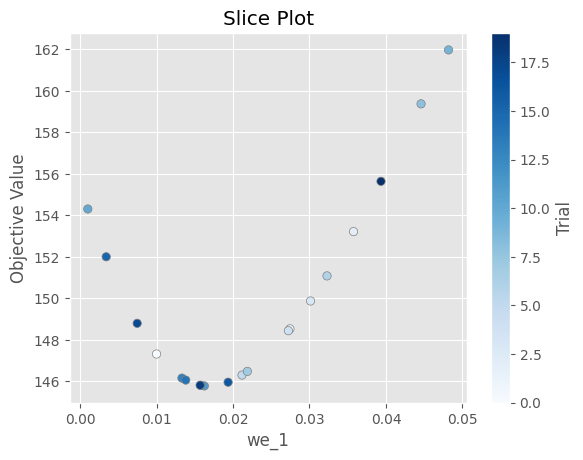

In [15]:
# Use the slice plot provided by optuna to visualize the values of the parameters
# considered within the optimization
plot_slice(study)

# Tune the recovery to baseline day and night data

Using the data split into day and night results, tune the recovery to each to see how the best fit changes under these different conditions.

#### Daytime result

In [16]:
mf_day = ModelFit(
    df_scada_baseline_day,
    fm,
    turbine_power_error_abs_004,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

opt_result_day, study_day = atomic_opt_optuna(mf_day, timeout=None, n_trials=n_trials)

we_1_baseline_day = opt_result_day["parameter_values"][0]

print(f"Best we_1 for day: {we_1_baseline_day}")


[I 2025-08-05 16:30:38,770] A new study created in memory with name: ModelFit
[I 2025-08-05 16:30:39,997] Trial 0 finished with value: 161.71906480689717 and parameters: {'we_1': 0.0393506087203139}. Best is trial 0 with value: 161.71906480689717.
[I 2025-08-05 16:30:41,118] Trial 1 finished with value: 157.21195009927368 and parameters: {'we_1': 0.02744067519636624}. Best is trial 1 with value: 157.21195009927368.
[I 2025-08-05 16:30:42,185] Trial 2 finished with value: 160.0501988497362 and parameters: {'we_1': 0.03575946831862097}. Best is trial 1 with value: 157.21195009927368.
[I 2025-08-05 16:30:43,261] Trial 3 finished with value: 157.96001012039906 and parameters: {'we_1': 0.030138168803582194}. Best is trial 1 with value: 157.21195009927368.
[I 2025-08-05 16:30:44,337] Trial 4 finished with value: 157.16458008496005 and parameters: {'we_1': 0.027244159149844845}. Best is trial 4 with value: 157.16458008496005.
[I 2025-08-05 16:30:45,395] Trial 5 finished with value: 156.262980

Best we_1 for day: 0.021182739966945238


#### Night results

In [17]:
mf_night = ModelFit(
    df_scada_baseline_night,
    fm,
    turbine_power_error_abs_004,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

opt_result_night, study_night = atomic_opt_optuna(mf_night, timeout=None, n_trials=n_trials)

we_1_baseline_night = opt_result_night["parameter_values"][0]

print(f"Best we_1 for night: {we_1_baseline_night}")

[I 2025-08-05 16:31:01,007] A new study created in memory with name: ModelFit
[I 2025-08-05 16:31:02,078] Trial 0 finished with value: 135.15875084075202 and parameters: {'we_1': 0.015260532398303512}. Best is trial 0 with value: 135.15875084075202.
[I 2025-08-05 16:31:03,112] Trial 1 finished with value: 140.05119628122227 and parameters: {'we_1': 0.02744067519636624}. Best is trial 0 with value: 135.15875084075202.
[I 2025-08-05 16:31:04,125] Trial 2 finished with value: 146.54528997622785 and parameters: {'we_1': 0.03575946831862097}. Best is trial 0 with value: 135.15875084075202.
[I 2025-08-05 16:31:05,164] Trial 3 finished with value: 141.97637301892055 and parameters: {'we_1': 0.030138168803582194}. Best is trial 0 with value: 135.15875084075202.
[I 2025-08-05 16:31:06,133] Trial 4 finished with value: 139.92160188516974 and parameters: {'we_1': 0.027244159149844845}. Best is trial 0 with value: 135.15875084075202.
[I 2025-08-05 16:31:07,129] Trial 5 finished with value: 136.574

Best we_1 for night: 0.015260532398303512


### Comparing the results

Notice the tuning parameters indicate less wake recovery in the night (smaller we_1) and more wake recovery in the day (larger we_1).

In [18]:
# Print a small table with the best parameters
print("Best parameters:")
print(f"All data: {we_1_baseline:.3f}")
print(f"Day data: {we_1_baseline_day:.3f}")
print(f"Night data: {we_1_baseline_night:.3f}")


Best parameters:
All data: 0.016
Day data: 0.021
Night data: 0.015


### Plot comparison

In [19]:
# The slice function is convenient but can also access the underlying data directly to make a custom plot
# First define a function to extract the data from the study object

# Extract data from each study
def extract_trial_data(study_obj, param_name):
    """Extract parameter values and costs from study trials."""
    param_values = [trial.params[param_name] for trial in study_obj.trials]
    cost_values = [trial.value for trial in study_obj.trials]

    # Sort both by parameter values
    param_values, cost_values = zip(*sorted(zip(param_values, cost_values)))

    # Get the best parameter value and cost
    best_param_value = study_obj.best_trial.params[param_name]
    best_cost = study_obj.best_trial.value

    # Normalize the cost values
    cost_values = np.array(cost_values) / np.min(cost_values)

    return param_values, cost_values, best_param_value, best_cost


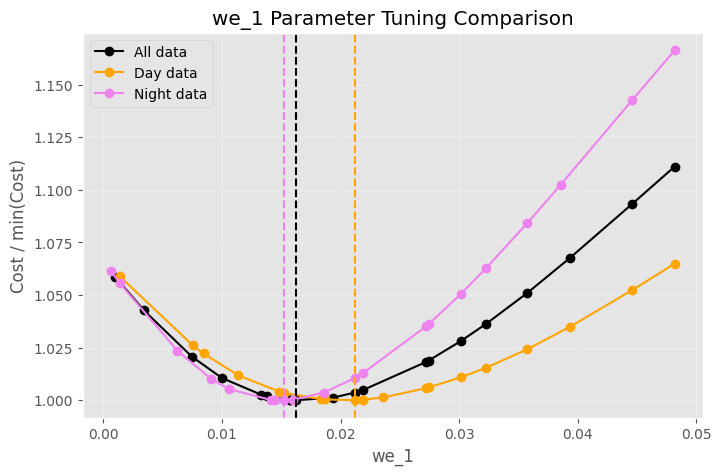

In [20]:
# Compare the results for we_1 in a single plot
fig, ax = plt.subplots(figsize=(8, 5))

# Get data for each study
all_data_params, all_data_costs, best_all_param, best_all_cost = extract_trial_data(study, "we_1")
day_params, day_costs, best_day_param, best_day_cost = extract_trial_data(study_day, "we_1")
night_params, night_costs, best_night_param, best_night_cost = extract_trial_data(
    study_night, "we_1"
)

# Create plots
ax.plot(all_data_params, all_data_costs, label="All data", marker="o", color="black")
ax.plot(day_params, day_costs, label="Day data", marker="o", color="orange")
ax.plot(night_params, night_costs, label="Night data", marker="o", color="violet")

ax.axvline(best_all_param, color="black", ls="--")
ax.axvline(best_day_param, color="orange", ls="--")
ax.axvline(best_night_param, color="violet", ls="--")

ax.set_title("we_1 Parameter Tuning Comparison")
ax.set_ylabel("Cost / min(Cost)")
ax.set_xlabel("we_1")
ax.legend()
ax.grid(True, alpha=0.3)

# Tune the deflection gain to the baseline data

The deflection gain in the emgauss model defines the gain in the deflection of the wake at the downstream turbine following a yaw angle misalignment.  A higher gain indicates more deflection of the wake.

## Update the FLORIS model with the best values of we_1 for each case from the baseline data

In [21]:
fm_baseline = fm.copy()
fm_baseline_day = fm.copy()
fm_baseline_night = fm.copy()

fm_baseline.set_param(parameter_list[0], we_1_baseline, 0)
fm_baseline_day.set_param(parameter_list[0], we_1_baseline_day, 0)
fm_baseline_night.set_param(parameter_list[0], we_1_baseline_night, 0)

## Tune the deflection parameter

First define the deflection parameter

In [22]:
# Just tune the first wake expansion parameter
parameter_list = [
    (
        "wake",
        "wake_deflection_parameters",
        "empirical_gauss",
        "horizontal_deflection_gain_D",
    )
]

parameter_name_list = [
    "deflection_gain",
]

parameter_range_list = [
    (0.0, 5.0),
]

parameter_index_list = [None]

## Also define the yaw angles to be resimulated in each case

In [23]:
# Set the yaw angle matrix for when using all the controlled data
yaw_vec = df_scada_controlled.wind_vane_005
yaw_angles_controlled = np.zeros((yaw_vec.shape[0], 7))
yaw_angles_controlled[:, 5] = yaw_vec  # Turbine 005 is the turbine implementing wake steering

# Set the yaw angles for day and night data
yaw_vec_day = df_scada_controlled_day.wind_vane_005
yaw_angles_controlled_day = np.zeros((yaw_vec_day.shape[0], 7))
yaw_angles_controlled_day[:, 5] = yaw_vec_day

yaw_vec_night = df_scada_controlled_night.wind_vane_005
yaw_angles_controlled_night = np.zeros((yaw_vec_night.shape[0], 7))
yaw_angles_controlled_night[:, 5] = yaw_vec_night

## Tune the deflection parameter

In [24]:
# Tune to all controlled data
mf_deflection = ModelFit(
    df_scada_controlled,
    fm_baseline,  # Use the model tuned to all baseline data
    turbine_power_error_abs_004,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles_controlled,
)

opt_result_deflection, study_deflection = atomic_opt_optuna(
    mf_deflection, timeout=None, n_trials=n_trials
)
def_gain = opt_result_deflection["parameter_values"][0]

[I 2025-08-05 16:31:22,439] A new study created in memory with name: ModelFit
[I 2025-08-05 16:31:24,165] Trial 0 finished with value: 156.15051623050013 and parameters: {'deflection_gain': 3.0}. Best is trial 0 with value: 156.15051623050013.
[I 2025-08-05 16:31:25,978] Trial 1 finished with value: 155.76085334141874 and parameters: {'deflection_gain': 2.7440675196366238}. Best is trial 1 with value: 155.76085334141874.
[I 2025-08-05 16:31:27,831] Trial 2 finished with value: 157.354099064636 and parameters: {'deflection_gain': 3.5759468318620975}. Best is trial 1 with value: 155.76085334141874.
[I 2025-08-05 16:31:29,681] Trial 3 finished with value: 156.17427785140535 and parameters: {'deflection_gain': 3.0138168803582195}. Best is trial 1 with value: 155.76085334141874.
[I 2025-08-05 16:31:31,483] Trial 4 finished with value: 155.73431184287864 and parameters: {'deflection_gain': 2.724415914984484}. Best is trial 4 with value: 155.73431184287864.
[I 2025-08-05 16:31:33,291] Trial 5

In [25]:
# Tune to the day data
mf_day = ModelFit(
    df_scada_controlled_day,
    fm_baseline_day,  # Use the model tuned to day-time baseline data
    turbine_power_error_abs_004,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles_controlled_day,
)

opt_result_deflection_day, study_deflection_day = atomic_opt_optuna(
    mf_day, timeout=None, n_trials=n_trials
)
def_gain_day = opt_result_deflection_day["parameter_values"][0]


[I 2025-08-05 16:31:58,867] A new study created in memory with name: ModelFit
[I 2025-08-05 16:31:59,820] Trial 0 finished with value: 173.3870846695458 and parameters: {'deflection_gain': 3.0}. Best is trial 0 with value: 173.3870846695458.
[I 2025-08-05 16:32:00,720] Trial 1 finished with value: 172.68273525652356 and parameters: {'deflection_gain': 2.7440675196366238}. Best is trial 1 with value: 172.68273525652356.
[I 2025-08-05 16:32:01,616] Trial 2 finished with value: 175.1781337349537 and parameters: {'deflection_gain': 3.5759468318620975}. Best is trial 1 with value: 172.68273525652356.
[I 2025-08-05 16:32:02,506] Trial 3 finished with value: 173.42705343854794 and parameters: {'deflection_gain': 3.0138168803582195}. Best is trial 1 with value: 172.68273525652356.
[I 2025-08-05 16:32:03,386] Trial 4 finished with value: 172.6314936358264 and parameters: {'deflection_gain': 2.724415914984484}. Best is trial 4 with value: 172.6314936358264.
[I 2025-08-05 16:32:04,264] Trial 5 fi

In [26]:
# Tune to the night data
mf_night = ModelFit(
    df_scada_controlled_night,
    fm_baseline_night,  # Use the model tuned to night-time baseline data
    turbine_power_error_abs_004,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles_controlled_night,
)
opt_result_deflection_night, study_deflection_night = atomic_opt_optuna(
    mf_night, timeout=None, n_trials=n_trials
)
def_gain_night = opt_result_deflection_night["parameter_values"][0]

[I 2025-08-05 16:32:17,113] A new study created in memory with name: ModelFit
[I 2025-08-05 16:32:18,082] Trial 0 finished with value: 140.20699029347787 and parameters: {'deflection_gain': 3.0}. Best is trial 0 with value: 140.20699029347787.
[I 2025-08-05 16:32:19,012] Trial 1 finished with value: 140.12374028055606 and parameters: {'deflection_gain': 2.7440675196366238}. Best is trial 1 with value: 140.12374028055606.
[I 2025-08-05 16:32:19,940] Trial 2 finished with value: 140.83053638268936 and parameters: {'deflection_gain': 3.5759468318620975}. Best is trial 1 with value: 140.12374028055606.
[I 2025-08-05 16:32:20,885] Trial 3 finished with value: 140.21576564762773 and parameters: {'deflection_gain': 3.0138168803582195}. Best is trial 1 with value: 140.12374028055606.
[I 2025-08-05 16:32:21,850] Trial 4 finished with value: 140.1214491727041 and parameters: {'deflection_gain': 2.724415914984484}. Best is trial 4 with value: 140.1214491727041.
[I 2025-08-05 16:32:22,790] Trial 5

# Compare the results for the deflection gain

Results indicate that the wake deflection gain is larger at night than at day.  

In [27]:
# Print a table with the best parameters
print("Best parameters:")
print(f"All data: {def_gain:.3f}")
print(f"Day data: {def_gain_day:.3f}")
print(f"Night data: {def_gain_night:.3f}")

Best parameters:
All data: 1.780
Day data: 0.412
Night data: 2.724


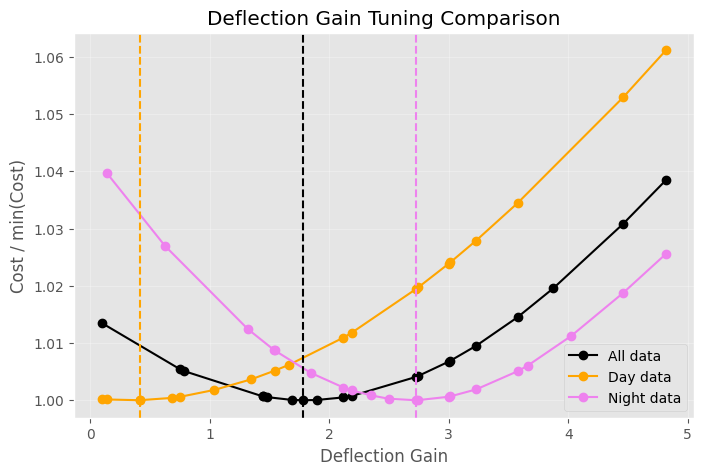

In [28]:
# Make comparison plot of the results

# Compare the results for deflection gain in a single plot
fig, ax = plt.subplots(figsize=(8, 5))

# Get data for each study
all_data_params, all_data_costs, best_all_param, best_all_cost = extract_trial_data(
    study_deflection, "deflection_gain"
)
day_params, day_costs, best_day_param, best_day_cost = extract_trial_data(
    study_deflection_day, "deflection_gain"
)
night_params, night_costs, best_night_param, best_night_cost = extract_trial_data(
    study_deflection_night, "deflection_gain"
)

# Create plots
ax.plot(all_data_params, all_data_costs, label="All data", marker="o", color="black")
ax.plot(day_params, day_costs, label="Day data", marker="o", color="orange")
ax.plot(night_params, night_costs, label="Night data", marker="o", color="violet")

ax.axvline(best_all_param, color="black", ls="--")
ax.axvline(best_day_param, color="orange", ls="--")
ax.axvline(best_night_param, color="violet", ls="--")

ax.set_title("Deflection Gain Tuning Comparison")
ax.set_ylabel("Cost / min(Cost)")
ax.set_xlabel("Deflection Gain")
ax.legend()
ax.grid(True, alpha=0.3)

# Simultaneously tune the we_1 and deflection gain parameters

As a final analysis, see what results would have been for all data case if we_1 and deflection were tuned simulaneously to the data

Note results would not be expected to be exactly the same because the data used in training is now not the same (instead of tuning expansion to baseline data and deflection_gain to controlled data, we are tuning both to all data)

In [29]:
# Redo parameter list to include both we_1 and deflection_gain
parameter_list = [
    (
        "wake",
        "wake_velocity_parameters",
        "empirical_gauss",
        "wake_expansion_rates",
    ),
    (
        "wake",
        "wake_deflection_parameters",
        "empirical_gauss",
        "horizontal_deflection_gain_D",
    ),
]

parameter_name_list = [
    "we_1",
    "deflection_gain",
]

parameter_range_list = [
    (0.0, 0.05),
    (0.0, 5.0),
]

parameter_index_list = [0, None]

In [30]:
# Redo yaw angle matrix to all data
yaw_vec = df_scada.wind_vane_005
yaw_angles_all = np.zeros((yaw_vec.shape[0], 7))
yaw_angles_all[:, 5] = yaw_vec


In [31]:
mf_simultaneous = ModelFit(
    df_scada,
    fm,
    turbine_power_error_abs_004,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles_all,
)

# Double the number of trials since tuning 2 parameters
opt_result_simultaneous, study_simultaneous = atomic_opt_optuna(
    mf_simultaneous, timeout=None, n_trials=n_trials * 2
)


[I 2025-08-05 16:32:36,341] A new study created in memory with name: ModelFit
[I 2025-08-05 16:32:40,301] Trial 0 finished with value: 161.80114077298285 and parameters: {'we_1': 0.03856888011860776, 'deflection_gain': 3.0}. Best is trial 0 with value: 161.80114077298285.
[I 2025-08-05 16:32:45,007] Trial 1 finished with value: 156.0725191106507 and parameters: {'we_1': 0.02744067519636624, 'deflection_gain': 3.5759468318620975}. Best is trial 1 with value: 156.0725191106507.
[I 2025-08-05 16:32:49,673] Trial 2 finished with value: 156.33281429052948 and parameters: {'we_1': 0.030138168803582194, 'deflection_gain': 2.724415914984484}. Best is trial 1 with value: 156.0725191106507.
[I 2025-08-05 16:32:54,359] Trial 3 finished with value: 153.25322176392444 and parameters: {'we_1': 0.021182739966945238, 'deflection_gain': 3.2294705653332807}. Best is trial 3 with value: 153.25322176392444.
[I 2025-08-05 16:32:59,052] Trial 4 finished with value: 155.72815391252473 and parameters: {'we_1'

/var/folders/zl/d69s6z796rs4fw08fnxrl0qxydms74/T/ipykernel_50079/1377690117.py:2: ExperimentalWarning: plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  plot_contour(study_simultaneous)


<Axes: title={'center': 'Contour Plot'}, xlabel='deflection_gain', ylabel='we_1'>

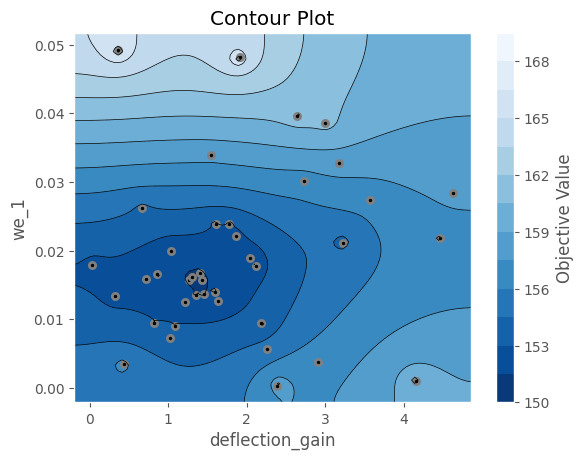

In [32]:
# Show the contour plot using the study object
plot_contour(study_simultaneous)

In [33]:
# Get the best parameters
we_1_simultaneous = opt_result_simultaneous["parameter_values"][0]
def_gain_simultaneous = opt_result_simultaneous["parameter_values"][1]


# Compare to the values computed sequentially
print("Sequential tuning results:")
print(f"Sequential tuning: {we_1_baseline:.3f}, {def_gain:.3f}")
print(f"Simultaneous tuning: {we_1_simultaneous:.3f}, {def_gain_simultaneous:.3f}")

Sequential tuning results:
Sequential tuning: 0.016, 1.780
Simultaneous tuning: 0.017, 1.408
